# Machine Learning Final Project
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

### Import Libraries

In [ ]:
# Import data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import other libraries
import json
from tqdm import tqdm

# Import Scikit-Learn libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Import TensorFlow libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

### Load Dataset

In [38]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)

## Step 1: Prepare Train/Test Split
First we fill prepare the columns which will be target variables (top nutrients and top ingredients)

Then we will prepare X using the feature columns, and for this first model we will use nutrients as the y for regression.

In [39]:
# Nutrient columns: all columns containing 'amount', excluding logs and package weight
nutrient_cols = [col for col in food_data.columns if ('amount' in col and not col.endswith('_log') and col != 'package_weight_amount')]
# Filter out nutrient columns with >90% zeros
nutrient_cols = [col for col in nutrient_cols if (food_data[col] == 0).mean() <= 0.9]
print(f'Nutrient columns selected ({len(nutrient_cols)}): {nutrient_cols}')

# Ingredient one-hot columns: all columns starting with 'ingredient_oh_'
ingredient_oh_cols = [col for col in food_data.columns if col.startswith('ingredient_oh_')]
# Filter out ingredient one-hot columns with >90% zeros
ingredient_oh_cols = [col for col in ingredient_oh_cols if (food_data[col] == 0).mean() <= 0.9]
print(f'Ingredient one-hot columns selected ({len(ingredient_oh_cols)}): {ingredient_oh_cols[:10]} ...')

# Feature columns: all columns except nutrient columns and dropped ingredient columns
exclude_cols = set(nutrient_cols)
exclude_cols.update(set(ingredient_oh_cols))
feature_cols = [col for col in food_data.columns if col not in exclude_cols]
print(f'Feature columns selected ({len(feature_cols)}): {feature_cols[:10]} ...')

Nutrient columns selected (15): ['Calcium, Ca amount', 'Carbohydrate, by difference amount', 'Cholesterol amount', 'Energy amount', 'Fatty acids, total saturated amount', 'Fiber, total dietary amount', 'Iron, Fe amount', 'Potassium, K amount', 'Protein amount', 'Sodium, Na amount', 'Sugars, added amount', 'Total Sugars amount', 'Total lipid (fat) amount', 'Vitamin A, IU amount', 'Vitamin C, total ascorbic acid amount']
Ingredient one-hot columns selected (8): ['ingredient_oh_salt', 'ingredient_oh_sugar', 'ingredient_oh_water', 'ingredient_oh_citricAcid', 'ingredient_oh_cornSyrup', 'ingredient_oh_naturalFlavor', 'ingredient_oh_soyLecithin', 'ingredient_oh_seaSalt'] ...
Feature columns selected (304): ['serving_size', 'Acetic acid amount', 'Alanine amount', 'Alcohol, ethyl amount', 'Arginine amount', 'Ash amount', 'Aspartic acid amount', 'Beta-glucans amount', 'Biotin amount', 'Caffeine amount'] ...


In [40]:
# Prepare X and y
X = food_data[feature_cols].values
y = food_data[nutrient_cols].values

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 2: Ensemble Model Part 1: Random Forest
The model being used for nutrient regression will be random forest regressor and Neural Network in an ensemble method. Both of the results from random forest and neural network are used as features in linear regression to combine their abilities.

In [41]:
# Utility function for batch generator for Random Forest training
def rf_batch_generator(X, y, batch_size=10000):
    num_rows = X.shape[0]
    for start in range(0, num_rows, batch_size):
        end = min(start + batch_size, num_rows)
        yield X[start:end], y[start:end]

In [43]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('Trained final Random Forest on full training set.')

# Predict on test set
y_pred_rf = rf.predict(X_test)

Trained final Random Forest on full training set.


In [44]:
# Calculate RMSE and R squared for Random Forest predictions
rmses_rf = [np.sqrt(mean_squared_error(y_test[:, i], y_pred_rf[:, i])) for i in range(y_test.shape[1])]
r2s_rf = [r2_score(y_test[:, i], y_pred_rf[:, i]) for i in range(y_test.shape[1])]

## Step 3: Ensemble Model Part 2: Neural Network
Uses KerasTuner, a library made to run several trials with the model to first find the best hyperparameters.

In [45]:
# Utility function for batch generator for NN training
def nn_batch_generator(X, y, batch_size=128):
    num_rows = X.shape[0]
    while True:
        for start in range(0, num_rows, batch_size):
            end = min(start + batch_size, num_rows)
            yield X[start:end], y[start:end]


In [50]:
# Use KerasTuner to find optimal NN hyperparameters
import keras_tuner as kt
def build_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units1', min_value=32, max_value=256, step=32), activation='relu'))
    model.add(Dropout(hp.Float('dropout1', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(hp.Int('units2', min_value=16, max_value=128, step=16), activation='relu'))
    model.add(Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(y_train.shape[1], activation='linear'))
    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])), loss='mse')
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='kt_dense_tuning',
    project_name='nutrient_dense'
    )

scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train)
X_test_nn = scaler.transform(X_test)

batch_size_nn = 128
train_gen_nn = nn_batch_generator(X_train_nn, y_train, batch_size=batch_size_nn)
val_gen_nn = nn_batch_generator(X_test_nn, y_test, batch_size=batch_size_nn)

steps_per_epoch = int(np.ceil(X_train_nn.shape[0] / batch_size_nn))
validation_steps = int(np.ceil(X_test_nn.shape[0] / batch_size_nn))

tuner.search(train_gen_nn, steps_per_epoch=steps_per_epoch, validation_data=val_gen_nn, validation_steps=validation_steps, epochs=20)

Trial 10 Complete [00h 06m 00s]
val_loss: 145.38572692871094

Best val_loss So Far: 138.2699432373047
Total elapsed time: 00h 47m 30s


In [51]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best hyperparameters:')
for hp_name in ['units1', 'units2', 'dropout1', 'dropout2', 'learning_rate']:
    if hp_name in best_hps.values:
        print(f"{hp_name}: {best_hps.get(hp_name)}")

Best hyperparameters:
units1: 224
units2: 128
dropout1: 0.1
dropout2: 0.1
learning_rate: 0.001


### Train Model using best hyperparameters

In [52]:
# Improved Neural Network for multi-output regression using best KerasTuner hyperparameters
print('Available hyperparameters:', list(best_hps.values.keys()))
best_units1 = best_hps.values.get('units1', 128)
best_units2 = best_hps.values.get('units2', 64)
best_dropout1 = best_hps.values.get('dropout1', 0.3)
best_dropout2 = best_hps.values.get('dropout2', 0.2)
best_lr = best_hps.values.get('learning_rate', 0.001)

scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train)
X_test_nn = scaler.transform(X_test)
model_nn = Sequential([
    Dense(best_units1, activation='relu'),
    Dropout(best_dropout1),
    Dense(best_units2, activation='relu'),
    Dropout(best_dropout2),
    Dense(y_train.shape[1], activation='linear')
])
model_nn.compile(optimizer=Adam(learning_rate=best_lr), loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

batch_size_nn = 128
steps_per_epoch = int(np.ceil(X_train_nn.shape[0] / batch_size_nn))
validation_steps = int(np.ceil(X_test_nn.shape[0] / batch_size_nn))
train_gen_nn = nn_batch_generator(X_train_nn, y_train, batch_size=batch_size_nn)
val_gen_nn = nn_batch_generator(X_test_nn, y_test, batch_size=batch_size_nn)
model_nn.fit(train_gen_nn, steps_per_epoch=steps_per_epoch, validation_data=val_gen_nn, validation_steps=validation_steps, epochs=40, callbacks=[early_stop, reduce_lr], verbose=1)
y_pred_nn = model_nn.predict(X_test_nn)

Available hyperparameters: ['units1', 'dropout1', 'units2', 'dropout2', 'learning_rate']
Epoch 1/40
12359/12359 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 245.6856 - val_loss: 326.9079 - learning_rate: 0.0010
Epoch 2/40
12359/12359 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 229.8548 - val_loss: 299.3293 - learning_rate: 0.0010
Epoch 3/40
12359/12359 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 207.0471 - val_loss: 187.8245 - learning_rate: 0.0010
Epoch 4/40
12359/12359 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 182.5387 - val_loss: 182.2303 - learning_rate: 0.0010
Epoch 5/40
12359/12359 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 176.3905 - val_loss: 234.2682 - learning_rate: 0.0010
Epoch 6/40
12331/12359 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 187.5921
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
12359/12359 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 175.8868 - val_loss: 193.0252 - learning_rate: 0.0010
Epoch 7/40
12359/12359 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - 

## Step 4: Ensemble Model Part 3: Linear Regression
Finally, the results from random forest and neural network are used in a linear regression model for enchanced predictions.

In [53]:
# Stacking ensemble: combine RF and NN predictions using Linear Regression as meta-model
ensemble_preds = []
ensemble_r2s = []
ensemble_rmses = []
for i in range(y_test.shape[1]):
    # Stack predictions from RF and NN as features
    X_meta = np.column_stack([y_pred_rf[:, i], y_pred_nn[:, i]])
    meta_model = LinearRegression()
    meta_model.fit(X_meta, y_test[:, i])
    y_pred_ensemble = meta_model.predict(X_meta)
    ensemble_preds.append(y_pred_ensemble)
    ensemble_r2s.append(r2_score(y_test[:, i], y_pred_ensemble))
    ensemble_rmses.append(np.sqrt(mean_squared_error(y_test[:, i], y_pred_ensemble)))
ensemble_preds = np.column_stack(ensemble_preds)
print('Stacking Ensemble RMSEs:')
for col, rmse in zip(nutrient_cols, ensemble_rmses):
    print(f'RMSE for {col}: {rmse:.4f}')
print('\nStacking Ensemble R squared:')
for col, r2 in zip(nutrient_cols, ensemble_r2s):
    print(f'R squared for {col}: {r2:.4f}')

Stacking Ensemble RMSEs:
RMSE for Calcium, Ca amount: 0.9958
RMSE for Carbohydrate, by difference amount: 22.0205
RMSE for Cholesterol amount: 0.0195
RMSE for Energy amount: 0.1623
RMSE for Fatty acids, total saturated amount: 4.7274
RMSE for Fiber, total dietary amount: 5.4388
RMSE for Iron, Fe amount: 0.1005
RMSE for Potassium, K amount: 0.0374
RMSE for Protein amount: 6.1228
RMSE for Sodium, Na amount: 0.0964
RMSE for Sugars, added amount: 7.0223
RMSE for Total Sugars amount: 14.8048
RMSE for Total lipid (fat) amount: 7.7199
RMSE for Vitamin A, IU amount: 0.0502
RMSE for Vitamin C, total ascorbic acid amount: 0.0322

Stacking Ensemble R squared:
R squared for Calcium, Ca amount: 0.8522
R squared for Carbohydrate, by difference amount: 0.7893
R squared for Cholesterol amount: 0.9958
R squared for Energy amount: 0.7083
R squared for Fatty acids, total saturated amount: 0.6985
R squared for Fiber, total dietary amount: 0.3517
R squared for Iron, Fe amount: 0.8864
R squared for Potassiu

## Step 5: Evaluate the Model
**RMSE (Root Mean Squared Error):**
- Measures the average magnitude of prediction errors (residuals) for the nutrient values.
- Lower RMSE means the model's predictions are closer to the true values.
- A more interprestable version of MSE

**R² (R Squared):**
- Indicates how well the model explains the variance in the true nutrient values.
- R² ranges from 0 to 1 (higher is better); values closer to 1 mean the model fits the data well.

In [54]:
# Random Forest stats
rf_mean_rmse = np.mean(rmses_rf)
rf_median_rmse = np.median(rmses_rf)
rf_mean_r2 = np.mean(r2s_rf)
rf_median_r2 = np.median(r2s_rf)
print(f'Random Forest Mean RMSE: {rf_mean_rmse:.4f}')
print(f'Random Forest Median RMSE: {rf_median_rmse:.4f}')
print(f'Random Forest Mean R^2: {rf_mean_r2:.4f}')
print(f'Random Forest Median R^2: {rf_median_r2:.4f}\n')

# Neural Network stats
nn_rmses = [np.sqrt(mean_squared_error(y_test[:, i], y_pred_nn[:, i])) for i in range(y_test.shape[1])]
nn_r2s = [r2_score(y_test[:, i], y_pred_nn[:, i]) for i in range(y_test.shape[1])]
nn_mean_rmse = np.mean(nn_rmses)
nn_median_rmse = np.median(nn_rmses)
nn_mean_r2 = np.mean(nn_r2s)
nn_median_r2 = np.median(nn_r2s)
print(f'Neural Network Mean RMSE: {nn_mean_rmse:.4f}')
print(f'Neural Network Median RMSE: {nn_median_rmse:.4f}')
print(f'Neural Network Mean R^2: {nn_mean_r2:.4f}')
print(f'Neural Network Median R^2: {nn_median_r2:.4f}\n')

# Ensemble stats
ensemble_mean_rmse = np.mean(ensemble_rmses)
ensemble_median_rmse = np.median(ensemble_rmses)
ensemble_mean_r2 = np.mean(ensemble_r2s)
ensemble_median_r2 = np.median(ensemble_r2s)
print(f'Ensemble Mean RMSE: {ensemble_mean_rmse:.4f}')
print(f'Ensemble Median RMSE: {ensemble_median_rmse:.4f}')
print(f'Ensemble Mean R^2: {ensemble_mean_r2:.4f}')
print(f'Ensemble Median R^2: {ensemble_median_r2:.4f}')

Random Forest Mean RMSE: 4.7018
Random Forest Median RMSE: 1.0452
Random Forest Mean R^2: 0.7999
Random Forest Median R^2: 0.8371

Neural Network Mean RMSE: 6.8881
Neural Network Median RMSE: 2.5833
Neural Network Mean R^2: 0.4302
Neural Network Median R^2: 0.4237

Ensemble Mean RMSE: 4.6234
Ensemble Median RMSE: 0.9958
Ensemble Mean R^2: 0.8181
Ensemble Median R^2: 0.8522


### Results Interpretation
#### Random Forest
- **Mean RMSE:** 4.7018 — On average, the prediction error for nutrients is 4.70 units.
- **Median RMSE:** 1.0452 — Half of the nutrients have prediction errors less than 1.05 units.
- **Mean R²:** 0.7999 — The model explains about 80% of the variance in nutrient values.
- **Median R²:** 0.8371 — For half of the nutrients, the model explains at least 83.7% of the variance.

#### Neural Network
- **Mean RMSE:** 6.8881 — Higher average error compared to Random Forest, indicating less accurate predictions overall.
- **Median RMSE:** 2.5833 — Half of the nutrients have errors below 2.58 units.
- **Mean R²:** 0.4302 — The model explains about 43% of the variance, which is lower than Random Forest.
- **Median R²:** 0.4237 — For half of the nutrients, the model explains at least 42.4% of the variance.

#### Ensemble (Stacked Model)
- **Mean RMSE:** 4.6234 — Slightly lower average error than Random Forest, showing improved accuracy.
- **Median RMSE:** 0.9958 — Half of the nutrients have errors below 1 unit.
- **Mean R²:** 0.8181 — Explains about 82% of the variance, outperforming both individual models.
- **Median R²:** 0.8522 — For half of the nutrients, the model explains at least 85.2% of the variance.

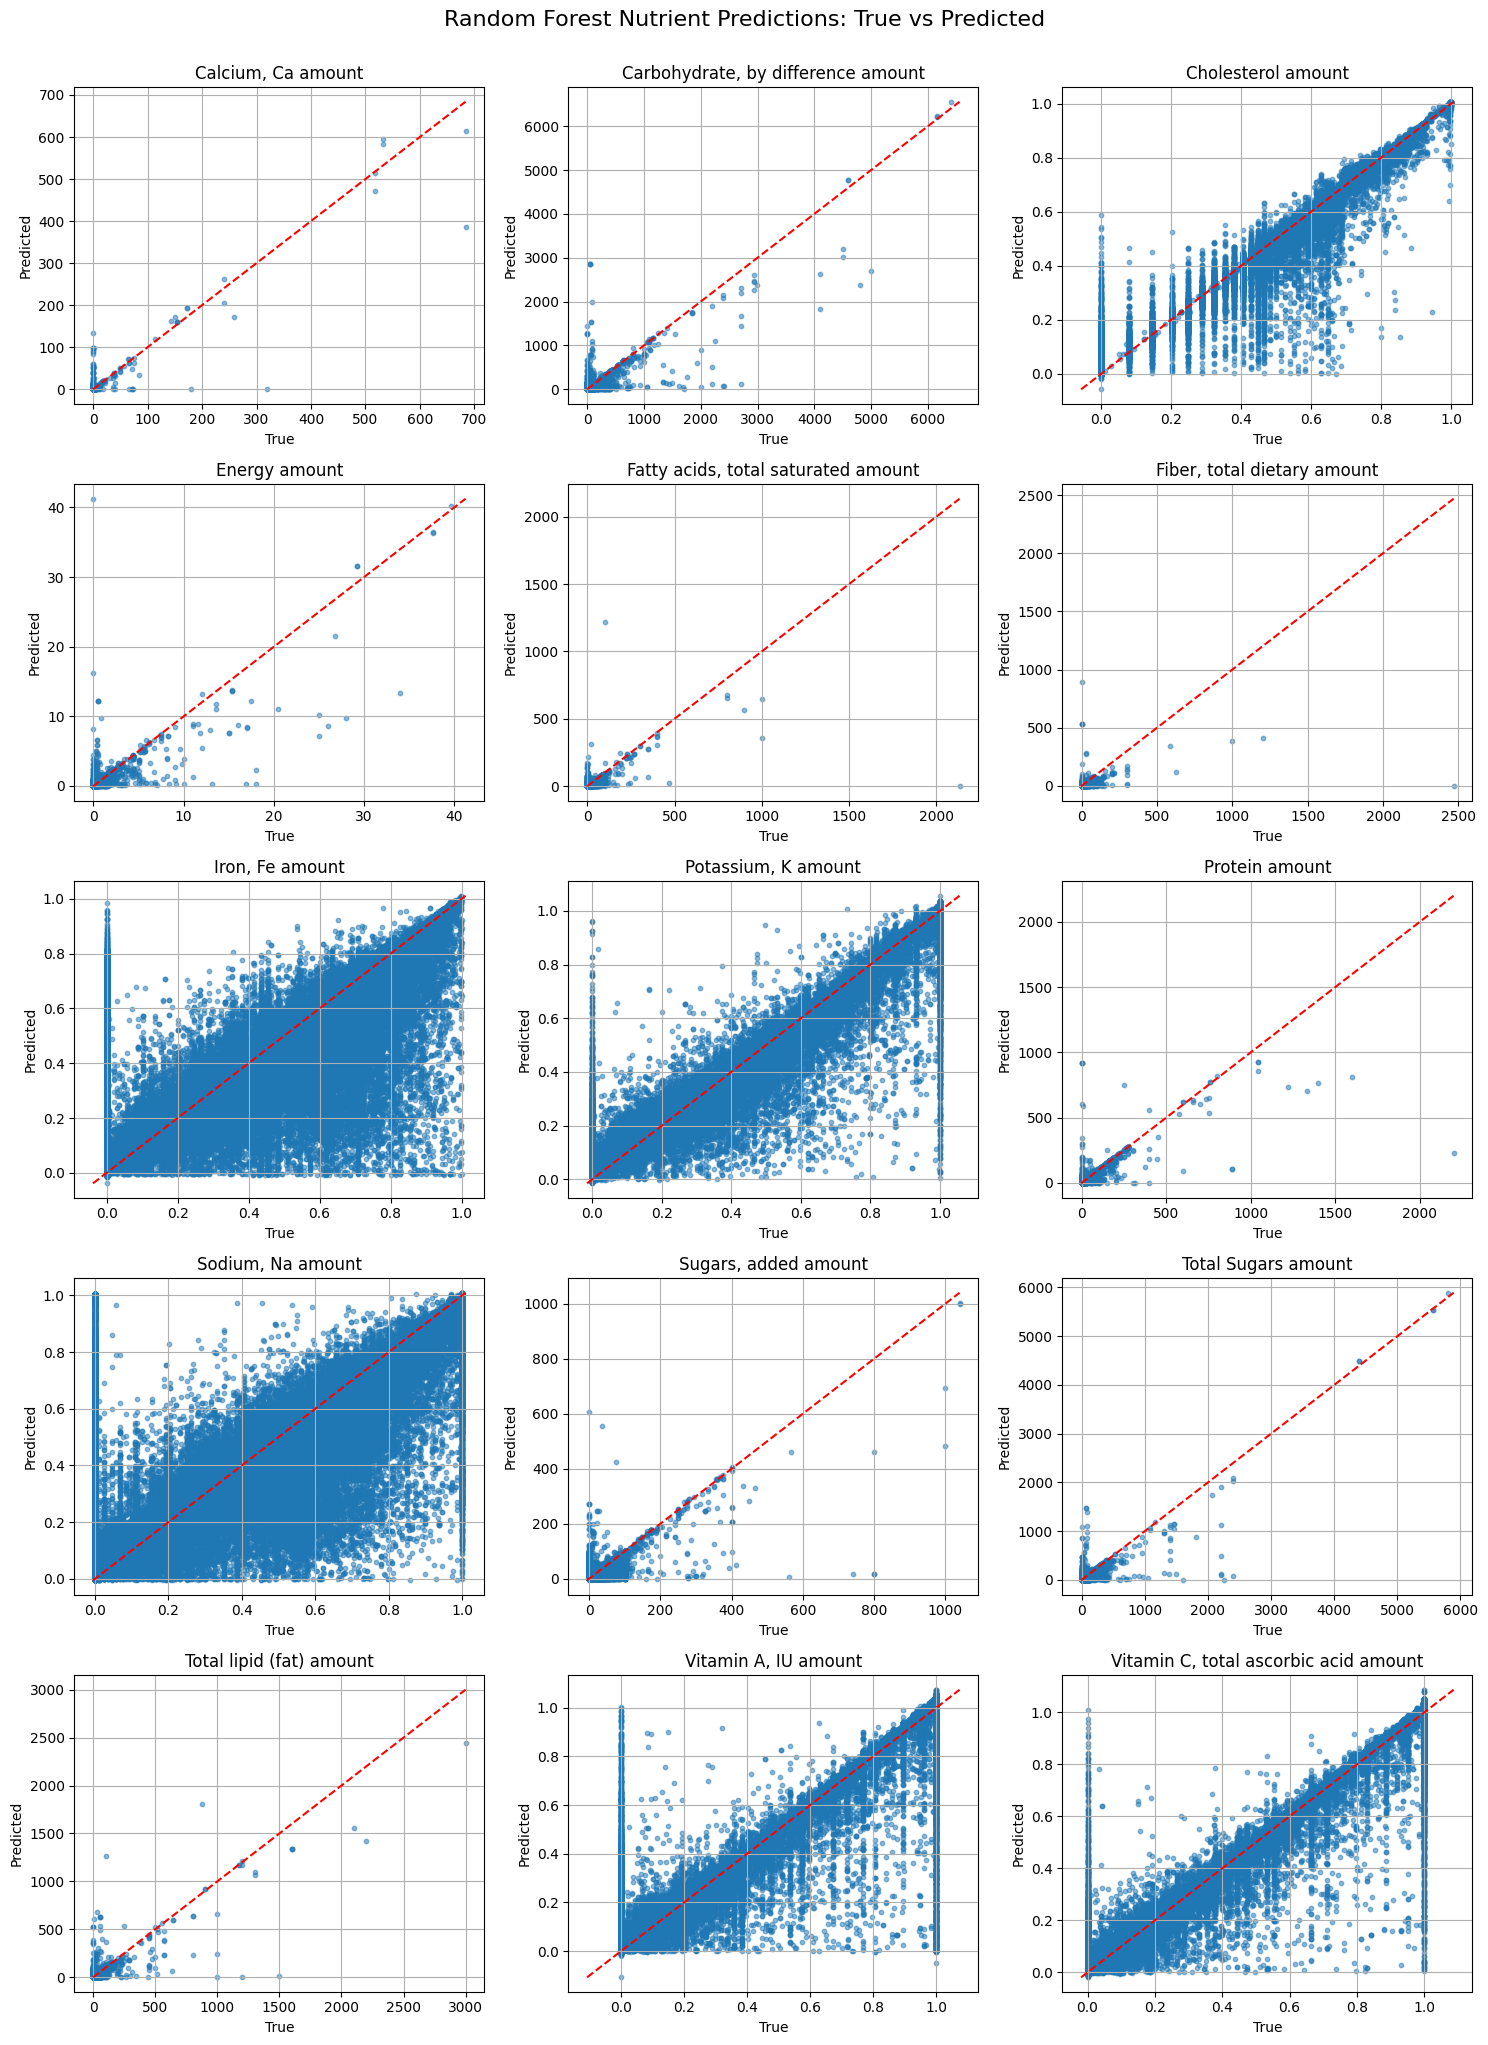

In [55]:
# Visualize Random Forest predictions: scatter plots for each nutrient
num_nutrients = len(nutrient_cols)
cols = 3
rows = int(np.ceil(num_nutrients / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(nutrient_cols):
    ax = axes[i]
    ax.scatter(y_test[:, i], ensemble_preds[:, i], alpha=0.5, s=10)
    min_val = min(np.min(y_test[:, i]), np.min(ensemble_preds[:, i]))
    max_val = max(np.max(y_test[:, i]), np.max(ensemble_preds[:, i]))
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_title(col)
    ax.grid(True)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Random Forest Nutrient Predictions: True vs Predicted', y=1.02, fontsize=16)
plt.show()

# Ingredient Classification

The following changes the target (y) to the top ingredients to predict if they are or aren't present.

This model only uses Random Forest, because it results in great evaluation metrics, and combining it with neural network could result in overfitting.

In [ ]:
# Prepare ingredient targets
y_ingredients = food_data[ingredient_oh_cols].values

# Train/test split for ingredients (same split as nutrients)
_, _, y_train_ing, y_test_ing = train_test_split(X, y_ingredients, test_size=0.2, random_state=42)

# Fit one-vs-rest Random Forest for each ingredient
rf_ing_models = []
y_pred_ing = np.zeros_like(y_test_ing)
for i in tqdm(range(y_train_ing.shape[1]), desc='Fitting Random Forest Models'):
    rf_ing = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_ing.fit(X_train, y_train_ing[:, i])
    y_pred_ing[:, i] = rf_ing.predict(X_test)
    rf_ing_models.append(rf_ing)

# Evaluate ingredient classification
ingredient_accs = [accuracy_score(y_test_ing[:, i], y_pred_ing[:, i]) for i in range(y_test_ing.shape[1])]
ingredient_precs = [precision_score(y_test_ing[:, i], y_pred_ing[:, i], zero_division=0) for i in range(y_test_ing.shape[1])]
ingredient_recs = [recall_score(y_test_ing[:, i], y_pred_ing[:, i], zero_division=0) for i in range(y_test_ing.shape[1])]
ingredient_f1s = [f1_score(y_test_ing[:, i], y_pred_ing[:, i], zero_division=0) for i in range(y_test_ing.shape[1])]

Fitting Random Forest Models: 100%|██████████| 8/8 [31:58<00:00, 239.76s/it]



In [ ]:
print('Random Forest Ingredient Classification Accuracy:')
for col, acc in zip(ingredient_oh_cols[:10], ingredient_accs[:10]):
    print(f'Accuracy for {col}: {acc:.4f}')

print('\nRandom Forest Ingredient Classification Precision:')
for col, prec in zip(ingredient_oh_cols[:10], ingredient_precs[:10]):
    print(f'Precision for {col}: {prec:.4f}')

print('\nRandom Forest Ingredient Classification Recall:')
for col, rec in zip(ingredient_oh_cols[:10], ingredient_recs[:10]):
    print(f'Recall for {col}: {rec:.4f}')

print('\nRandom Forest Ingredient Classification F1 Score:')
for col, f1 in zip(ingredient_oh_cols[:10], ingredient_f1s[:10]):
    print(f'F1 Score for {col}: {f1:.4f}')

Random Forest Ingredient Classification Accuracy:
Accuracy for ingredient_oh_salt: 0.9999
Accuracy for ingredient_oh_sugar: 0.9999
Accuracy for ingredient_oh_water: 0.9999
Accuracy for ingredient_oh_citricAcid: 0.9871
Accuracy for ingredient_oh_cornSyrup: 0.9952
Accuracy for ingredient_oh_naturalFlavor: 0.9889
Accuracy for ingredient_oh_soyLecithin: 0.9958
Accuracy for ingredient_oh_seaSalt: 0.9886

Random Forest Ingredient Classification Precision:
Precision for ingredient_oh_salt: 0.9998
Precision for ingredient_oh_sugar: 0.9999
Precision for ingredient_oh_water: 0.9999
Precision for ingredient_oh_citricAcid: 0.9778
Precision for ingredient_oh_cornSyrup: 0.9888
Precision for ingredient_oh_naturalFlavor: 0.9788
Precision for ingredient_oh_soyLecithin: 0.9892
Precision for ingredient_oh_seaSalt: 0.9665

Random Forest Ingredient Classification Recall:
Recall for ingredient_oh_salt: 1.0000
Recall for ingredient_oh_sugar: 0.9998
Recall for ingredient_oh_water: 0.9997
Recall for ingredient

In [ ]:
print(f'\nMean Ingredient Accuracy: {np.mean(ingredient_accs):.4f}')
print(f'Mean Ingredient Precision: {np.mean(ingredient_precs):.4f}')
print(f'Mean Ingredient Recall: {np.mean(ingredient_recs):.4f}')
print(f'Mean Ingredient F1 Score: {np.mean(ingredient_f1s):.4f}')


Mean Ingredient Accuracy: 0.9944
Mean Ingredient Precision: 0.9876
Mean Ingredient Recall: 0.9684
Mean Ingredient F1 Score: 0.9778


### Metrics Overview
- **Accuracy:** Proportion of total predictions that were correct. High accuracy means most ingredients were classified correctly.
- **Precision:** Of all ingredients predicted as present, the proportion that were actually present. High precision means few false positives.
- **Recall:** Of all ingredients that were actually present, the proportion that were correctly identified. High recall means few false negatives.
- **F1 Score:** Harmonic mean of precision and recall. Balances both metrics, especially useful when classes are imbalanced.

### Results Interpretation
- **Mean Ingredient Accuracy:** 0.9944 — The model correctly classified ingredients 99.44% of the time.
- **Mean Ingredient Precision:** 0.9876 — When the model predicts an ingredient is present, it is correct 98.76% of the time.
- **Mean Ingredient Recall:** 0.9684 — The model identifies 96.84% of all actual ingredients present.
- **Mean Ingredient F1 Score:** 0.9778 — The overall balance between precision and recall is very high, indicating strong classification performance.